In [1]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
galaxy = nicegalaxy.Galaxy(342447)

In [6]:
galaxy.gas["Coordinates"].max(axis=0) - galaxy.gas["Coordinates"].min(axis=0)

array([541.1187105 , 541.11975878, 541.11986088])

In [5]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)

fig, ax = plt.subplots()
structured_gas = nicegalaxy.structured_column(galaxy.gas["Coordinates"], galaxy.gas["Density"], grid_size=500)
scalebar_length = round(box_length/10)
scalebar_pixels = scalebar_length/box_length * structured_gas.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
im = ax.imshow(np.log10(structured_gas) + 10, cmap="Blues_r", interpolation=None)
ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\mathrm{log}(\rho_{\mathrm{col}}) [M_{\odot}/\mathrm{kpc}^3]$")
fig.savefig(f"cutout-images/whole.png", bbox_inches='tight', dpi=500)
plt.close(fig)

Slicing: 100%|██████████| 500/500 [01:03<00:00,  7.91it/s]


In [ ]:
b1 = nicegalaxy.compressive_ratio_measurment1(galaxy.gas["Velocities"][~galaxy.disk_mask], galaxy.gas["Density"][~galaxy.disk_mask], galaxy.gas["Masses"][~galaxy.disk_mask], galaxy.gas["InternalEnergy"][~galaxy.disk_mask], bulk_v=galaxy.bhs["Velocities"][0])

In [ ]:
b1

In [ ]:
struct_col = nicegalaxy.structured_column(galaxy.rotated_gas_coords, galaxy.gas["Velocities"][:, 0] - galaxy.bhs["Velocities"][0][0], grid_size=300, x_lim=(-25, 25), y_lim=(-25, 25), z_lim=(-25, 25))

In [ ]:
plt.imshow(struct_col, cmap="RdBu")
plt.colorbar()

In [ ]:
plt.imshow(struct_col, cmap="RdBu")
plt.colorbar()

In [ ]:
np.mean(galaxy.gas["Velocities"], axis=0)

In [ ]:
galaxy.bhs["Velocities"][0][0]

In [149]:
min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
initial_indices = np.arange(len(galaxy.gas["Coordinates"]))

result_tree = galaxy.subdivide_box(initial_indices, threshold=16**3, bounds=(min_corner, max_corner))

/tmp/ipykernel_59363/1660132209.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data=df[(df["c0"] > 0e-1)], x='Level', y="rms_mach", palette='viridis')


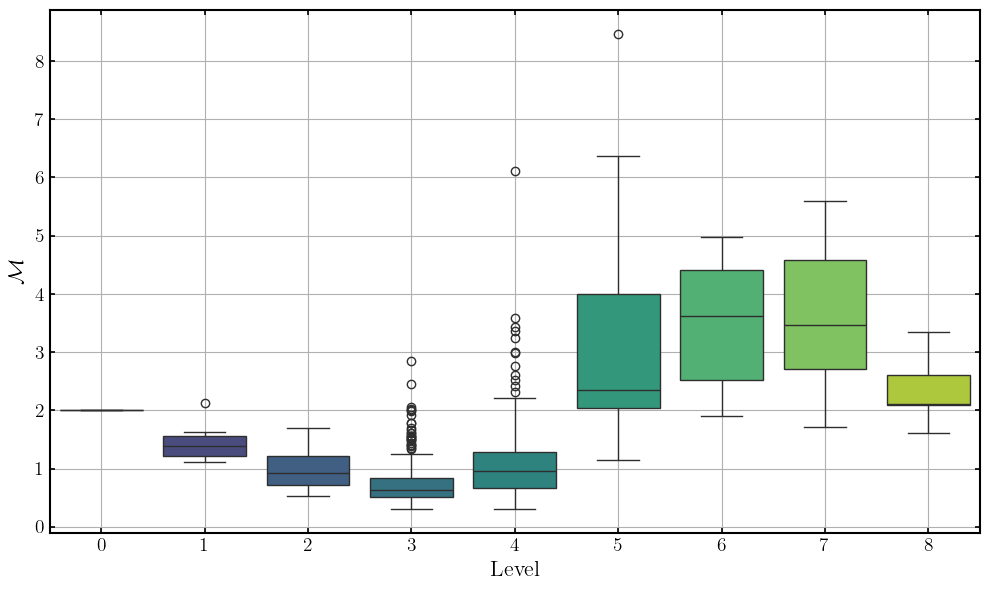

In [239]:
def collect_level_values(tree, level_values=None):
    """Recursively extract level and value from the tree"""
    if level_values is None:
        level_values = []

    if not isinstance(tree, list):
        return level_values

    node = tree[0]
    level = node['level']
    b1 = node['b1']
    b2 = node['b2']
    sfr = node["sfr"]
    nums = node["nums"]
    rms_mach = node["rms_mach"]
    dens_var = node["dens_var"]
    mean_dens = node["mean_dens"]
    c0 = node["c0"]
    level_values.append((level, b1, rms_mach, dens_var, mean_dens, c0, b2, sfr, nums))

    for child in tree[1:]:
        collect_level_values(child, level_values)

    return level_values

# Suppose this is your result tree from the recursive subdivision
# result_tree = subdivide_box(...)

# Step 1: Extract level/value data
level_value_pairs = collect_level_values(result_tree)

# Step 2: Convert to DataFrame
df = pd.DataFrame(level_value_pairs, columns=['Level', 'b1', "rms_mach", "dens_var", "mean_dens", "c0", "b2", "sfr", "nums"])

# Step 3: Make violin plot
plt.figure(figsize=(10, 6))
plot = sns.boxplot(data=df[(df["c0"] > 0e-1)], x='Level', y="rms_mach", palette='viridis')
plt.xlabel('Level')
plt.ylabel(r'$\mathcal{M}$')
# plt.ylim(0, 1.1)
plt.grid(True)
# plt.yscale("log")
# plt.axhline(y=0.3333, color="red", linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()
fig = plot.get_figure()
fig.savefig("octtree_machnumber.pdf")

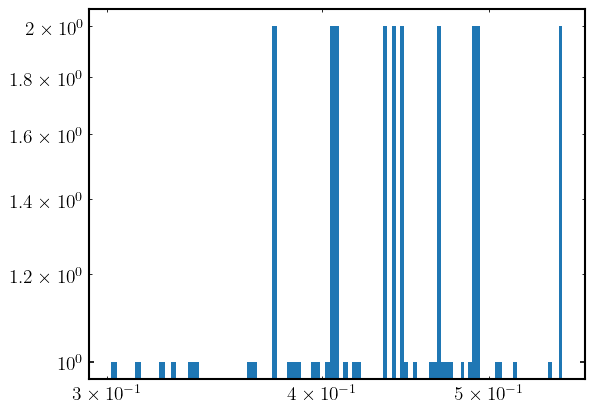

In [160]:
plt.hist(df[(df["sfr"] < 1e-10) & (df["nums"] > 20**3) & (df["c0"] > 3e-1)]["c0"], bins=100)
plt.yscale("log")
plt.xscale("log")
plt.show()

In [212]:
good = df[(df["c0"] > 3e-1) & (df["Level"] == 2)]
len(good)
good

,Level,b1,rms_mach,dens_var,mean_dens,c0,b2,sfr,nums
4,2,0.552638,0.736893,3.868552e-08,9.499549e-08,0.366437,0.625917,0.0,38269
124,2,0.507126,0.862395,3.442791e-08,7.872067e-08,0.402820,0.219324,0.0,31760
139,2,0.445572,0.687070,6.220608e-08,2.031957e-07,0.374029,0.479633,0.0,83372
333,2,0.891104,0.521003,1.352494e-08,2.913178e-08,0.405609,0.492160,0.0,11953
334,2,0.741426,0.712121,1.300829e-08,2.463759e-08,0.328371,0.292464,0.0,10272
389,2,0.798280,0.760178,8.177272e-09,1.347528e-08,0.369945,0.343736,0.0,5518
390,2,0.549459,0.948644,8.488734e-09,1.628563e-08,0.379109,0.334834,0.0,6858
395,2,0.787802,0.634458,2.338279e-08,4.678170e-08,0.311712,0.250473,0.0,19041


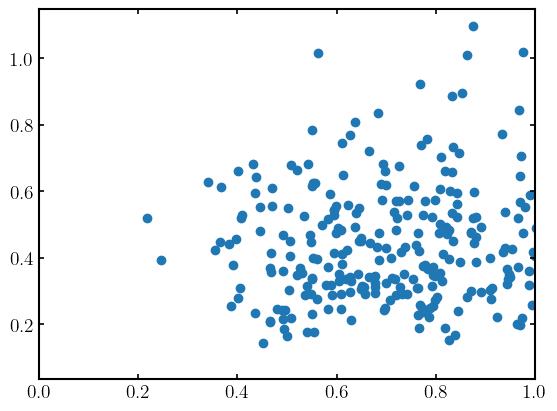

In [210]:
good = df[(df["c0"] > 0e-1)]
plt.scatter(good["b1"], good["b2"])
plt.xlim(0, 1)
plt.show()

In [ ]:

galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

In [ ]:
541/64

/tmp/ipykernel_59363/55977435.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


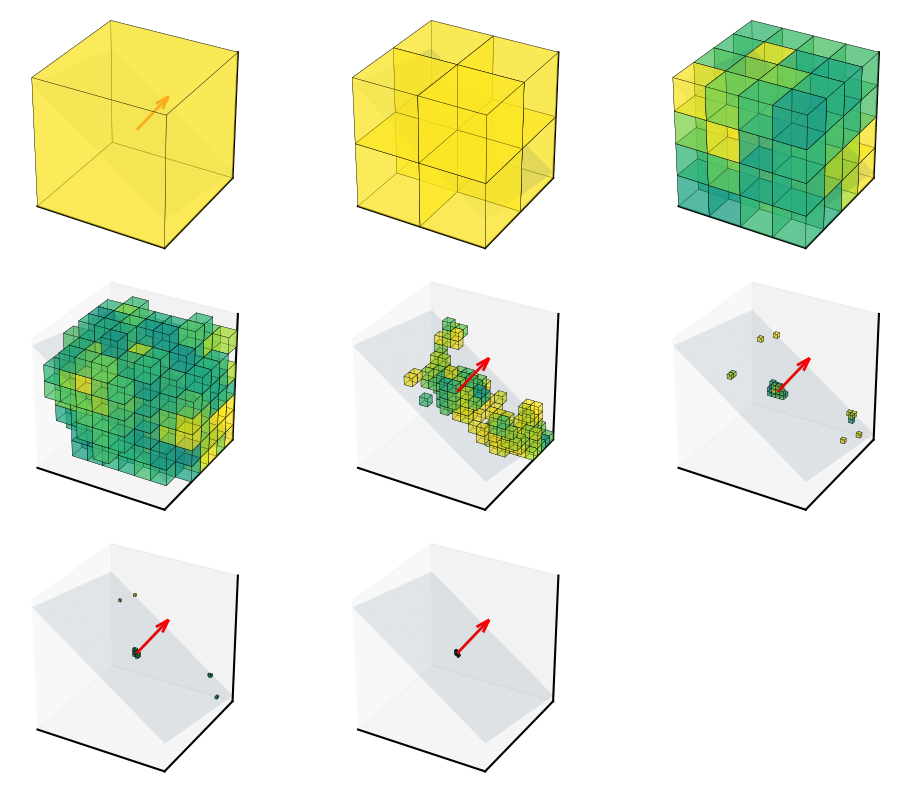

In [244]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.cm as cm

# Step 1: Collect level-6 boxes
def collect_level_boxes(tree, target_level=6, boxes=None):
    if boxes is None:
        boxes = []
    if not isinstance(tree, list):
        return boxes

    node = tree[0]
    if node['level'] == target_level:
        boxes.append(node)
    for child in tree[1:]:
        collect_level_boxes(child, target_level, boxes)
    return boxes


# Step 2: Define function to draw 3D boxes
def draw_3d_boxes(boxes, ax, vmin=None, vmax=None):
    norm = plt.Normalize(vmin, vmax)
    cmap = cm.get_cmap('viridis')

    for box in boxes:
        (xmin, ymin, zmin), (xmax, ymax, zmax) = box['bounds']
        value = np.log(box['b1'])
        color = cmap(norm(value))

        # Define the corners of the box
        verts = np.array([
            [xmin, ymin, zmin], [xmax, ymin, zmin],
            [xmax, ymax, zmin], [xmin, ymax, zmin],
            [xmin, ymin, zmax], [xmax, ymin, zmax],
            [xmax, ymax, zmax], [xmin, ymax, zmax]
        ])
        # Faces as lists of vertex indices
        faces = [
            [verts[i] for i in [0,1,2,3]],
            [verts[i] for i in [4,5,6,7]],
            [verts[i] for i in [0,1,5,4]],
            [verts[i] for i in [2,3,7,6]],
            [verts[i] for i in [1,2,6,5]],
            [verts[i] for i in [4,7,3,0]],
        ]

        poly = Poly3DCollection(faces, facecolor=color, edgecolor='k', linewidths=0.2, alpha=0.5)
        ax.add_collection3d(poly)

# Step 3: Plot it
cols = 3
rows = (8 + cols - 1) // cols
fig = plt.figure(figsize=(10, 8))
for i, level in enumerate(list(range(0, 8))):
    ax = fig.add_subplot(rows, cols, i+1, projection='3d')
    level_6_boxes = collect_level_boxes(result_tree, target_level=level)
    values = [box['b1'] for box in level_6_boxes]
    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")
    # ax.set_zlabel("Z")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_xlim(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max())
    ax.set_ylim(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max())
    ax.set_zlim(galaxy.gas["Coordinates"][:, 2].min(), galaxy.gas["Coordinates"][:, 2].max())
    ax.set_box_aspect([1, 1, 1])

    ax.quiver(galaxy.bhs["Coordinates"][0, 0], galaxy.bhs["Coordinates"][0, 1], galaxy.bhs["Coordinates"][0, 2], 200*galaxy.normal_vector[0]/np.linalg.norm(galaxy.normal_vector), 200*galaxy.normal_vector[1]/np.linalg.norm(galaxy.normal_vector), 200*galaxy.normal_vector[2]/np.linalg.norm(galaxy.normal_vector), color='r')
    
    normal = galaxy.normal_vector/np.linalg.norm(galaxy.normal_vector)

    point  = galaxy.bhs["Coordinates"][0]
    d = -point.dot(normal)
    xx, yy = np.meshgrid(np.linspace(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max(), 100), np.linspace(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max(), 100))
    z = (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]
    ax.plot_surface(xx, yy, z, alpha=0.1)
    draw_3d_boxes(level_6_boxes, ax, vmin=np.log10(0.001), vmax=np.log10(20))


plt.tight_layout()
plt.show()
fig.savefig("octtree.pdf")

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
level_6_boxes = collect_level_boxes(result_tree, target_level=5)
values = [box['b1'] for box in level_6_boxes]
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

ax.set_xlim(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max())
ax.set_ylim(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max())
ax.set_zlim(galaxy.gas["Coordinates"][:, 2].min(), galaxy.gas["Coordinates"][:, 2].max())
ax.set_box_aspect([1, 1, 1])

ax.quiver(galaxy.bhs["Coordinates"][0, 0], galaxy.bhs["Coordinates"][0, 1], galaxy.bhs["Coordinates"][0, 2], 200*galaxy.normal_vector[0]/np.linalg.norm(galaxy.normal_vector), 200*galaxy.normal_vector[1]/np.linalg.norm(galaxy.normal_vector), 200*galaxy.normal_vector[2]/np.linalg.norm(galaxy.normal_vector), color='r')

normal = galaxy.normal_vector/np.linalg.norm(galaxy.normal_vector)

point  = galaxy.bhs["Coordinates"][0]
d = -point.dot(normal)
xx, yy = np.meshgrid(np.linspace(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max(), 100), np.linspace(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max(), 100))
z = (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]
ax.plot_surface(xx, yy, z, alpha=0.1)
draw_3d_boxes(level_6_boxes, ax, vmin=np.log10(0.001), vmax=np.log10(20))
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation

def update(frame):
    ax.view_init(elev=30, azim=frame)
    return fig,

ani = FuncAnimation(fig, update, frames=range(0, 360, 2), interval=50)
plt.show()

In [ ]:
ani.save('rotation.mp4', writer='ffmpeg')

In [ ]:
wind = galaxy.stars["Coordinates"][galaxy.stars["GFM_StellarFormationTime"] <= 0]

In [ ]:
plt.scatter(wind[:, 0], wind[:, 1])
plt.scatter(galaxy.bhs["Coordinates"][:, 0], galaxy.bhs["Coordinates"][:, 1])

In [ ]:
np.mean(galaxy.gas["StarFormationRate"][galaxy.gas["StarFormationRate"] > 0])

In [ ]:
struct_col = nicegalaxy.structured_column(galaxy.gas["Coordinates"][galaxy.gas["StarFormationRate"] < 1e-10], galaxy.gas["StarFormationRate"][galaxy.gas["StarFormationRate"] < 1e-10], grid_size=500)

In [ ]:
plt.imshow(np.log10(struct_col))

In [98]:
np.mean(galaxy.gas["Machnumber"][galaxy.gas["Machnumber"] > 0])

np.float32(3.2629306)

In [96]:
len(galaxy.gas["Machnumber"])

5337697

In [97]:
77286/5337697

0.01447927823553866

In [132]:
bounds = [np.array([24955.9350742 ,  5736.80302446, 34096.40712977]), np.array([24955.9350742 ,  5736.80302446, 34096.40712977]) + 25]
positions = galaxy.gas["Coordinates"]
density = galaxy.gas["Density"]
velocities = galaxy.gas["Velocities"]
internal_energy = galaxy.gas["InternalEnergy"]
grid_density = nicegalaxy.map_unstructured_to_structured_3d_batched(positions, density, grid_size=(100, 100, 100), batches=1, bounds=bounds, disable=True)
soundspeed = np.sqrt(5/3 * (5/3 - 1) * internal_energy)
mach_sq = np.sum((velocities - np.mean(velocities, axis=0))**2, axis=-1)/soundspeed**2
grid_mach_sq = nicegalaxy.map_unstructured_to_structured_3d_batched(positions, mach_sq, grid_size=(100, 100, 100), batches=1, bounds=bounds, disable=True)
mean_dens = np.mean(grid_density)
dens_var = np.std(grid_density)
rms_mach = np.sqrt(np.mean(grid_mach_sq))
b1_1 = (1/rms_mach) * dens_var/mean_dens

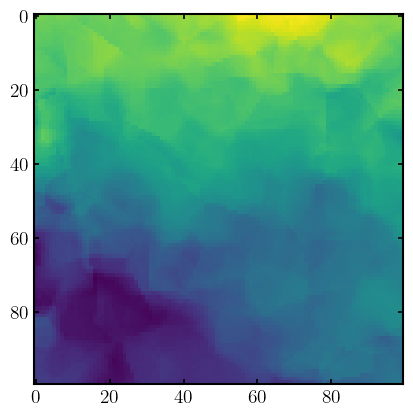

In [133]:
plt.imshow(np.log(grid_density.sum(axis=-1)))
plt.show()

(array([6.5420e+03, 5.0400e+02, 7.3600e+02, 1.0300e+02, 5.8860e+03,
        0.0000e+00, 1.2430e+04, 5.3150e+03, 3.7960e+03, 7.0150e+03,
        1.0242e+04, 3.9120e+03, 9.0170e+03, 1.5543e+04, 9.6870e+03,
        6.4650e+03, 7.5330e+03, 1.0355e+04, 9.0020e+03, 1.3290e+04,
        1.8632e+04, 1.3651e+04, 2.0885e+04, 1.2790e+04, 2.8147e+04,
        3.6043e+04, 2.0480e+04, 2.1319e+04, 1.1795e+04, 2.8404e+04,
        1.6572e+04, 2.2589e+04, 2.1486e+04, 1.5703e+04, 8.8480e+03,
        1.7857e+04, 2.7345e+04, 1.5625e+04, 2.4927e+04, 2.4018e+04,
        1.3531e+04, 1.5013e+04, 2.5116e+04, 1.8241e+04, 1.7472e+04,
        2.1174e+04, 1.7308e+04, 1.2241e+04, 1.5425e+04, 2.6503e+04,
        1.8993e+04, 8.2930e+03, 3.4660e+04, 1.7399e+04, 2.2266e+04,
        1.0569e+04, 1.6809e+04, 1.0723e+04, 1.9101e+04, 1.5530e+04,
        1.8377e+04, 4.3670e+03, 1.2402e+04, 4.2430e+03, 6.7080e+03,
        3.0750e+03, 7.4630e+03, 3.4970e+03, 1.2710e+03, 1.7820e+03,
        1.3120e+03, 1.4870e+03, 2.2760e+03, 2.15

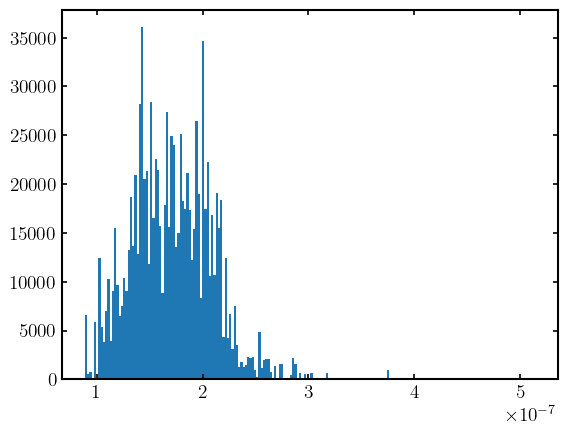

In [134]:
plt.hist(grid_density.flatten(), bins=200)

In [135]:
mean_dens/dens_var

np.float32(4.5362554)

In [136]:
len(np.unique(grid_density.ravel()))/100**3

0.000718

1000000
